# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [42]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

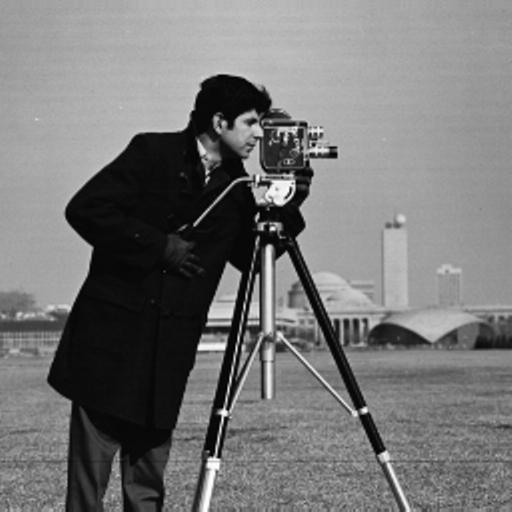

In [43]:
img = Image.open("cameraman.png")
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [44]:
# Get the size of the image

width, height = img.size
print("Original size:", img.size)

# scaling factors

cx = 2
cy = 2

Original size: (512, 512)


In [45]:
# ── 1. Increase size (scale ×2) ────────────────────

new_width = int(width * cx)
new_height = int(height * cy)

# Resize the image using PIL's built-in method
scaled_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)



Original size: (512, 512)
Scaled size: (1024, 1024)


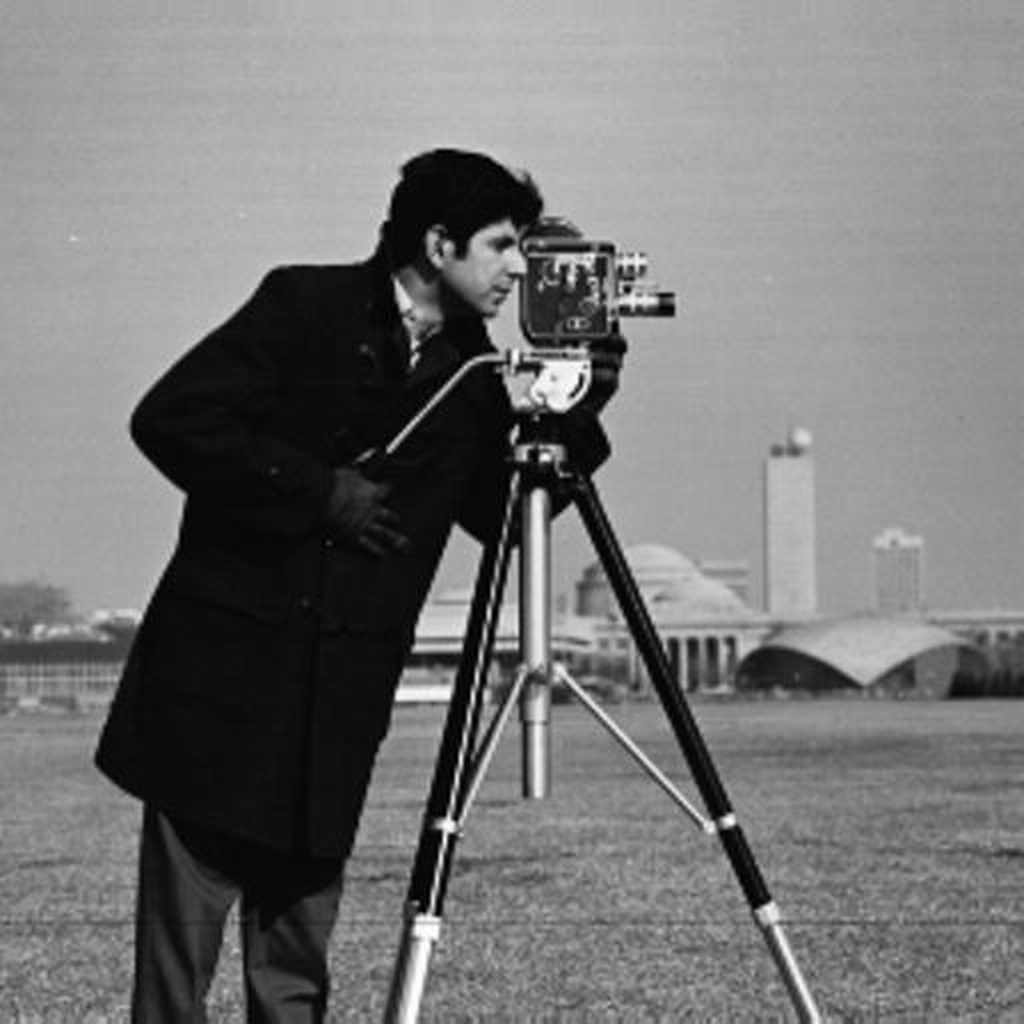

In [46]:
# Save the scaled image
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

display(scaled_img)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [47]:
cx = 2
cy = 1

new_width = int(width * cx)
new_height = int(height * cy)


In [48]:
non_uniform_img = img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)


Original size: (512, 512)
Non-uniform scaled size: (1024, 512)


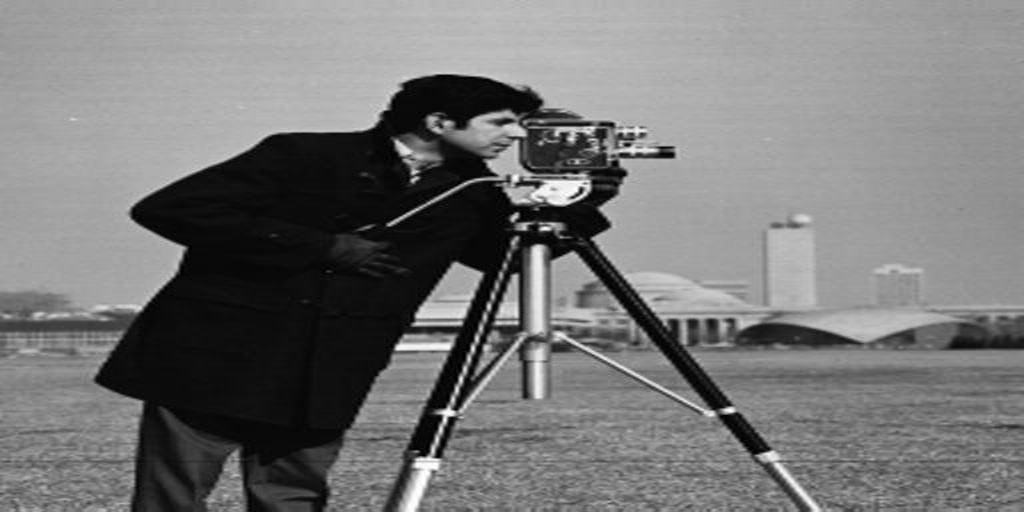

In [49]:
print("Original size:", img.size)
print("Non-uniform scaled size:", non_uniform_img.size)

display(non_uniform_img)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


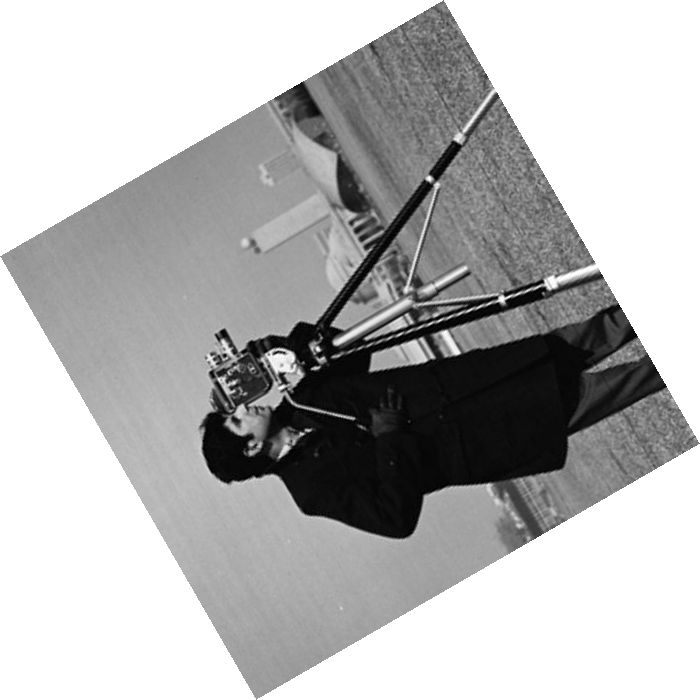

In [50]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_img = img.rotate(
    120,
    expand=True,
    resample=Image.Resampling.BICUBIC,
    fillcolor=255
)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

display(rotated_img)

### 3. Shear

In [51]:
# -- c. Get the image dimensions ────────────────────

width, height = img.size

print("Width:", width)
print("Height:", height)

Width: 512
Height: 512


In [52]:
# -- d. define the shear matrix ──────────────────────────

shear_factor = 0.5

shear_matrix = (
    1, -shear_factor, 0,
    0, 1, 0
)

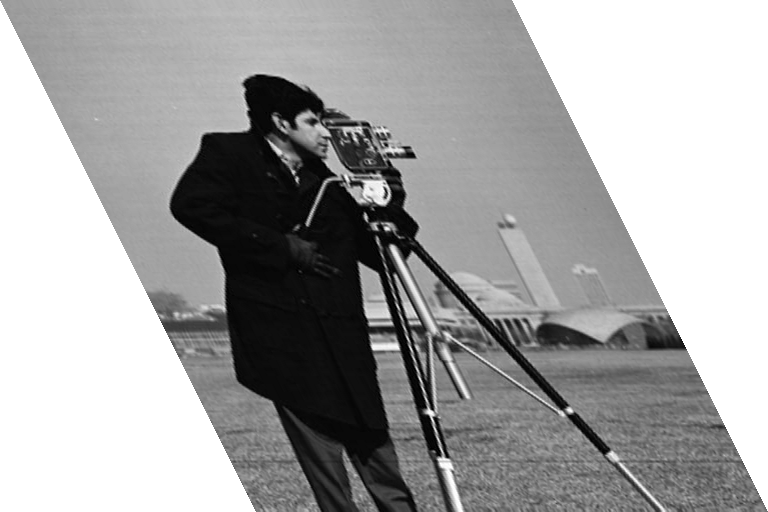

In [53]:
# -- e. Apply the shear transformation to the image ──────────────────────────

new_width = int(width + abs(shear_factor) * height)
new_height = height

sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=255
)

display(sheared_img)


In [54]:
# -- f. Save the sheared image

sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

X-axis shear factor = 0.1


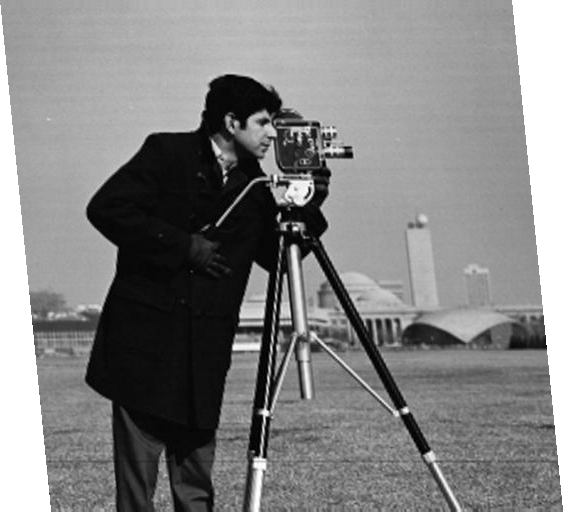

X-axis shear factor = 0.3


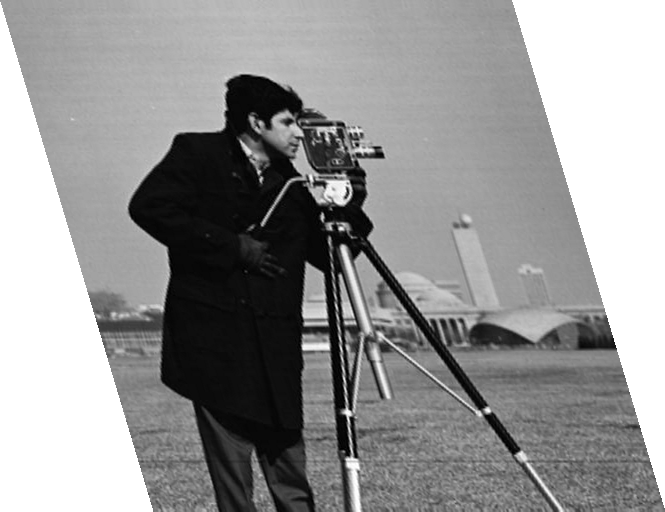

X-axis shear factor = 0.8


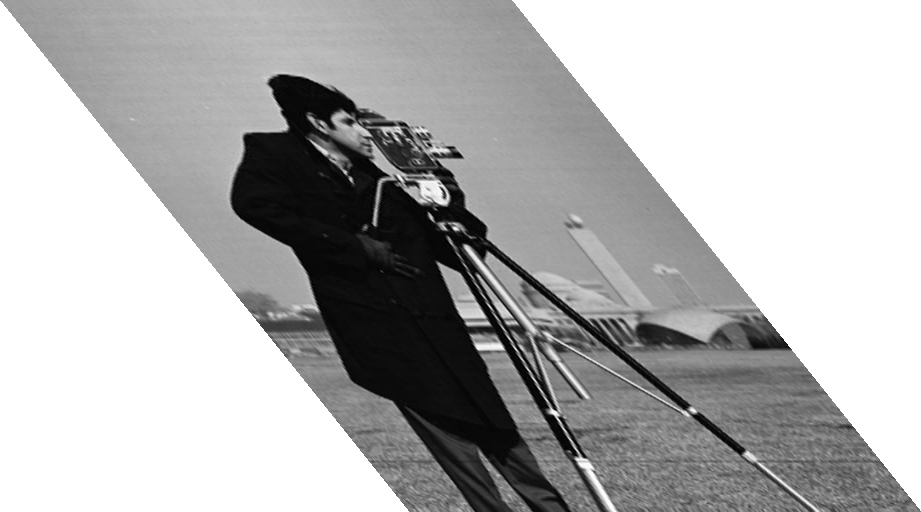

In [55]:
shear_factors = [0.1, 0.3, 0.8]

for shear_factor in shear_factors:
    
    new_width = int(width + abs(shear_factor) * height)
    new_height = height

    shear_matrix = (
        1, -shear_factor, 0,
        0, 1, 0
    )

    result = img.transform(
        (new_width, new_height),
        Image.Transform.AFFINE,
        shear_matrix,
        resample=Image.Resampling.BICUBIC,
        fillcolor=255
    )

    print("X-axis shear factor =", shear_factor)
    display(result)

shear_factor = 0.5

new_width = width
new_height = int(height + abs(shear_factor) * width)

y_shear_matrix = (
    1, 0, 0,
    -shear_factor, 1, 0
)

y_sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    y_shear_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=255
)

display(y_sheared_img)

In [56]:
new_width = int(width + abs(shear_factor) * height)
new_height = height

new_width = width
new_height = int(height + abs(shear_factor) * width)

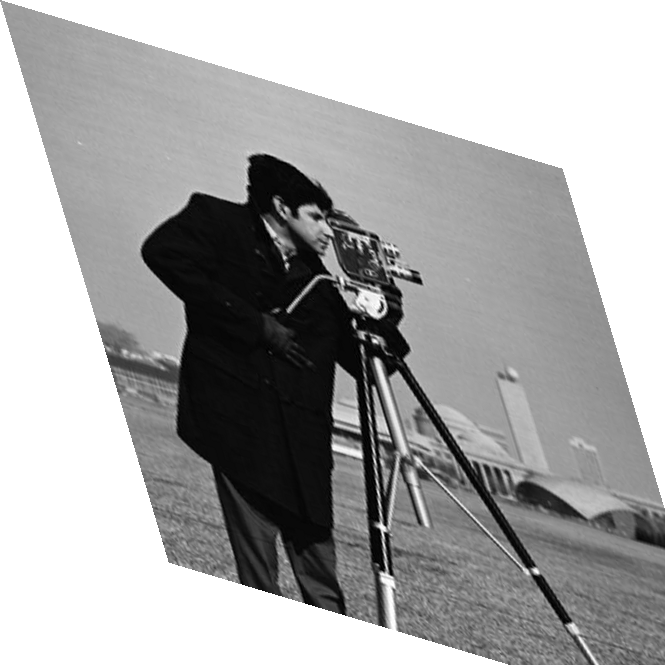

In [57]:
shx = 0.3
shy = 0.3

new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

xy_shear_matrix = (
    1, -shx, 0,
    -shy, 1, 0
)

xy_sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    xy_shear_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=255
)

display(xy_sheared_img)

# Intensity Transformations
Negative · Log · Power Law (Gamma)

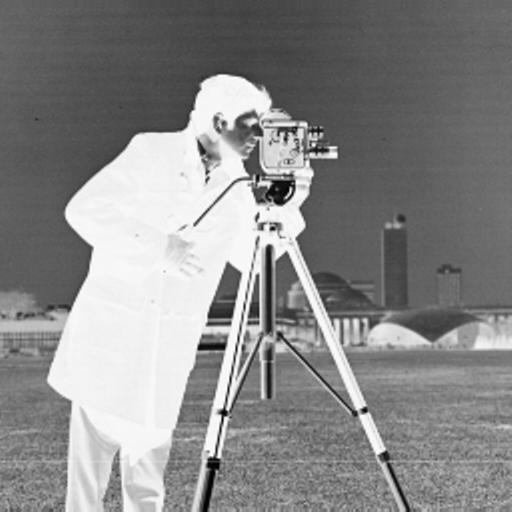

In [58]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

arr = np.array(img)

negative_arr = 255 - arr
negative_img = Image.fromarray(negative_arr.astype(np.uint8))

display(negative_img)


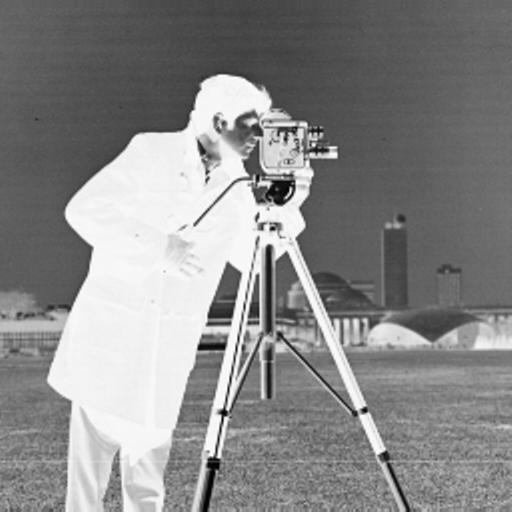

In [59]:
# Method 2: PIL's ImageOps

negative_pil = ImageOps.invert(img)

display(negative_pil)

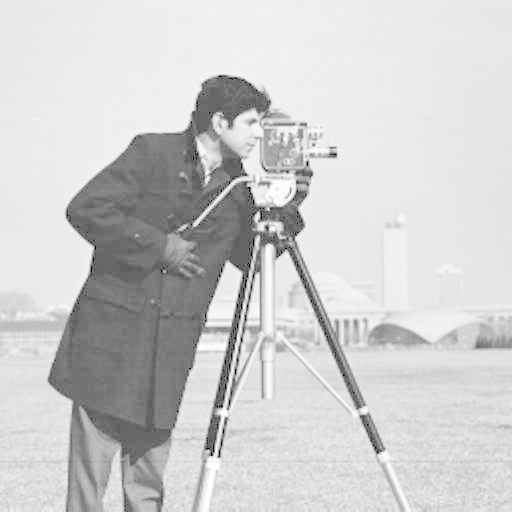

In [ ]:
# ── 2. Log transformation ──────────────────────────

arr = np.array(img).astype(np.float32)
# s = c * log(1 + r)
c = 255 / np.log(1 + 255)
log_transformed_arr = c * np.log1p(arr)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255)
log_transformed_img = Image.fromarray(
    log_transformed_arr.astype(np.uint8)
)

display(log_transformed_img)

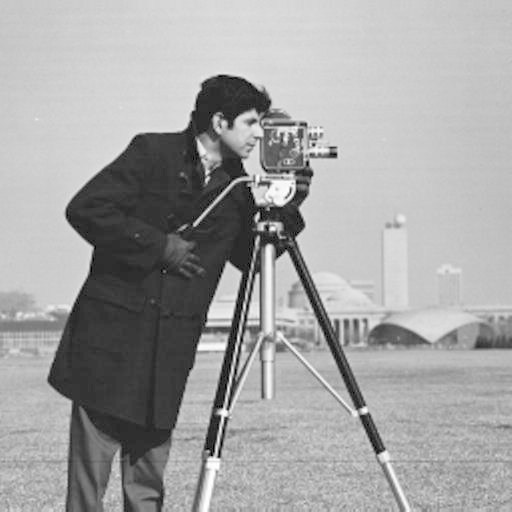

In [61]:
# ── 3. Power-law / Gamma correction ───────────────

arr = np.array(img).astype(np.float32)
gamma = 0.5
gamma_arr = 255 * ((arr / 255.0) ** gamma)
gamma_arr = np.clip(gamma_arr, 0, 255)
gamma_img = Image.fromarray(
    gamma_arr.astype(np.uint8)
)

display(gamma_img)